In [1]:
%load_ext autoreload
%autoreload 2


# Trading Competition Training

Train Nash-DQN and locally linear-quadratic SRE-DQN on the shared trading competition environment.

In [2]:
from pathlib import Path
import sys
import time

import matplotlib.pyplot as plt
import numpy as np
import torch


def find_repo_root(start):
    start = Path(start).resolve()
    for path in [start, *start.parents]:
        if (path / 'AGENTS.md').exists() and (path / 'continuous_action_space').exists():
            return path
    raise RuntimeError('Could not locate repo root')


REPO_ROOT = find_repo_root(Path.cwd())
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

EXPERIMENT_DIR = REPO_ROOT / 'continuous_action_space' / 'trading_competition'
MODEL_ROOT = EXPERIMENT_DIR / 'pt_files'
MODEL_ROOT.mkdir(parents=True, exist_ok=True)

np.set_printoptions(precision=4)
print('Repo root:', REPO_ROOT)
print('Model root:', MODEL_ROOT)
print('Using device:', 'cuda' if torch.cuda.is_available() else 'cpu')


Repo root: /home/wowthecoder/SRE-DQN
Model root: /home/wowthecoder/SRE-DQN/continuous_action_space/trading_competition/pt_files
Using device: cuda


## Imports And Helpers


In [3]:
from continuous_action_space.trading_competition.experiment_config import (
    NUM_PLAYERS as num_players,
    sim_dict,
    norm_mean,
    norm_std,
    T,
    make_sim_obj,
    seed_everything,
    configure_torch_gpu_math,
    eps_slug,
    seed_slug,
    BASE_SEED,
    MAX_STEPS,
    LLQ_SRE_EPS_LIST,
    SRE_EPS_REG,
    SRE_DELTA_MIN,
    SRE_GAMMA,
    NET_KWARGS,
)
from continuous_action_space.trading_competition.training import run_training_loop
from continuous_action_space.locally_linear_quadratic.NashAgent_lib import NashNN
from continuous_action_space.locally_linear_quadratic.sre_agent import SreNN

configure_torch_gpu_math()
sim_obj = make_sim_obj()


def make_nash_action(agent, eps_b, noise_std):
    del eps_b
    def fn(cur_s, cur_ivt):
        mu = agent.predict_action(cur_s, cur_ivt)[:, 4]
        return mu + torch.randn_like(mu) * noise_std
    return fn


def make_llq_sre_action(agent, eps_b, noise_std):
    def fn(cur_s, cur_ivt):
        mu_sr = agent.compute_sre_action(cur_s, cur_ivt, eps_b)
        return mu_sr + torch.randn_like(mu_sr) * noise_std
    return fn


def make_eps_schedule(eps_0):
    def eps_schedule(k, num_sim):
        if SRE_EPS_DECAY is None:
            return eps_0
        return eps_0 * max(0.0, 1.0 - k / max(SRE_EPS_DECAY, 1))
    return eps_schedule


print('Agents:', num_players, '| T=', sim_dict['T'].item(), '| dt=', sim_dict['dt'].item(), '| impact=', sim_obj.impact)

Agents: 5 | T= 5 | dt= 0.5 | impact= sqrt


## Training Configuration


In [4]:
NASH_SEED = BASE_SEED
LLQ_SRE_TRAIN_SEED = BASE_SEED

NUM_SIM = 10000
RV_MIN = 0.5
RV_MAX = 2.5
EARLY_STOP = True
EARLY_LIM = 3000
MINI_BATCH = 128
SRE_EPS_DECAY = None

TRAINING_LOG_KWARGS = dict(
    loss_log_every=1000,
    eval_reward_every=200,
    eval_episodes=500,
    log_best_updates=False,
    log_weight_saves=False,
)

NASH_RUN_TAG = seed_slug(NASH_SEED)
LLQ_SRE_RUN_TAG = seed_slug(LLQ_SRE_TRAIN_SEED)

NASH_MODEL_DIR = MODEL_ROOT / f'nash_{NASH_RUN_TAG}'
LLQ_SRE_MODEL_DIRS = {
    eps: MODEL_ROOT / f'llq_sre_eps_{eps_slug(eps)}_{LLQ_SRE_RUN_TAG}'
    for eps in LLQ_SRE_EPS_LIST
}

seed_everything(BASE_SEED)
print('NUM_SIM:', NUM_SIM, '| MAX_STEPS:', MAX_STEPS, '| MINI_BATCH:', MINI_BATCH)
print('LLQ Epsilon sweep:', LLQ_SRE_EPS_LIST, '| decay horizon:', SRE_EPS_DECAY)
print('Nash dir:', NASH_MODEL_DIR)

NUM_SIM: 10000 | MAX_STEPS: 10 | MINI_BATCH: 128
LLQ Epsilon sweep: [0.0, 0.01, 0.1, 0.5, 1.0] | decay horizon: None
Nash dir: /home/wowthecoder/SRE-DQN/continuous_action_space/trading_competition/pt_files/nash_seed_42


## Train Nash-DQN


In [5]:
nash_agent = None
nash_loss = None
nash_train_time = None

NASH_MODEL_DIR.mkdir(parents=True, exist_ok=True)
seed_everything(NASH_SEED)
nash_agent = NashNN(**NET_KWARGS)
start = time.time()
nash_agent, nash_loss = run_training_loop(
    sim_obj=sim_obj,
    sim_dict=sim_dict,
    max_steps=MAX_STEPS,
    agent=nash_agent,
    make_action_fn=make_nash_action,
    eps_schedule_fn=None,
    num_sim=NUM_SIM,
    norm_mean=norm_mean,
    norm_std=norm_std,
    rv_min=RV_MIN,
    rv_max=RV_MAX,
    early_stop=EARLY_STOP,
    early_lim=EARLY_LIM,
    mini_batch=MINI_BATCH,
    path=str(NASH_MODEL_DIR),
    AN_file_name=str(NASH_MODEL_DIR / 'Action_Net'),
    VN_file_name=str(NASH_MODEL_DIR / 'Value_Net'),
    checkpoint_metadata={'trainer': 'nash_dqn', 'seed': int(NASH_SEED)},
    desc='Nash-DQN',
    **TRAINING_LOG_KWARGS,
)
nash_train_time = time.time() - start
print(f'Nash-DQN training time: {nash_train_time:.1f}s')


CUDA IS AVAILABLE!


Nash-DQN:   0%|          | 0/10000 [00:00<?, ?it/s]

/home/wowthecoder/SRE-DQN/continuous_action_space/locally_linear_quadratic/NashAgent_lib.py:149: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  ids = torch.tensor(torch.arange(self.num_players)).tile(num_entries).cuda()


Nash-DQN Episode 1000 | Total Loss 4983.5908 | V_loss 2491.1016 | A_loss 2492.4893
Nash-DQN Best so far | Episode 998 | Loss 3139.6475
Nash-DQN Eval rewards | Episode 1000 | Mean -1.5146 | Std 2.8010 | Agent means [-1.454, -1.347, -1.603, -1.607, -1.563]
Nash-DQN Episode 2000 | Total Loss 1117.0327 | V_loss 559.6762 | A_loss 557.3565
Nash-DQN Best so far | Episode 1974 | Loss 940.5260
Nash-DQN Eval rewards | Episode 2000 | Mean -1.3679 | Std 2.7788 | Agent means [-1.347, -1.393, -1.487, -1.301, -1.311]
Nash-DQN Episode 3000 | Total Loss 1141.8171 | V_loss 576.3000 | A_loss 565.5172
Nash-DQN Best so far | Episode 2381 | Loss 823.0865
Nash-DQN Eval rewards | Episode 3000 | Mean -1.4115 | Std 2.8353 | Agent means [-1.618, -1.397, -1.432, -1.129, -1.481]
Nash-DQN Episode 4000 | Total Loss 1204.6138 | V_loss 606.6783 | A_loss 597.9354
Nash-DQN Best so far | Episode 2381 | Loss 823.0865
Nash-DQN Eval rewards | Episode 4000 | Mean -1.3670 | Std 2.7838 | Agent means [-1.2  , -1.464, -1.299, -1

## Train Locally Linear-Quadratic SRE-DQN


In [6]:
llq_sre_agents = {}
llq_sre_losses = {}
llq_sre_train_times = {}

for eps in LLQ_SRE_EPS_LIST:
    eps_dir = LLQ_SRE_MODEL_DIRS[eps]
    eps_dir.mkdir(parents=True, exist_ok=True)

    seed_everything(LLQ_SRE_TRAIN_SEED)
    sre_agent = SreNN(
        **NET_KWARGS,
        eps_reg=SRE_EPS_REG,
        delta_min=SRE_DELTA_MIN,
        gamma=SRE_GAMMA,
    )

    start = time.time()
    trained_agent, train_loss = run_training_loop(
        sim_obj=sim_obj,
        sim_dict=sim_dict,
        max_steps=MAX_STEPS,
        agent=sre_agent,
        make_action_fn=make_llq_sre_action,
        eps_schedule_fn=make_eps_schedule(eps),
        num_sim=NUM_SIM,
        norm_mean=norm_mean,
        norm_std=norm_std,
        rv_min=RV_MIN,
        rv_max=RV_MAX,
        early_stop=EARLY_STOP,
        early_lim=EARLY_LIM,
        mini_batch=MINI_BATCH,
        path=str(eps_dir),
        AN_file_name=str(eps_dir / f'LLQ_SRE_Action_Net_eps_{eps_slug(eps)}'),
        VN_file_name=str(eps_dir / f'LLQ_SRE_Value_Net_eps_{eps_slug(eps)}'),
        checkpoint_metadata={
            'trainer': 'llq_sre_dqn',
            'seed': int(LLQ_SRE_TRAIN_SEED),
            'eps_0': float(eps),
            'eps_decay_horizon': None if SRE_EPS_DECAY is None else int(SRE_EPS_DECAY),
            'eps_reg': float(SRE_EPS_REG),
            'delta_min': float(SRE_DELTA_MIN),
            'gamma': float(SRE_GAMMA),
        },
        desc=f'LLQ SRE-DQN eps={eps:g}',
        **TRAINING_LOG_KWARGS,
    )
    llq_sre_agents[eps] = trained_agent
    llq_sre_losses[eps] = train_loss
    llq_sre_train_times[eps] = time.time() - start
    print(f'LLQ SRE-DQN training time (eps={eps:g}): {llq_sre_train_times[eps]:.1f}s')


CUDA IS AVAILABLE!


LLQ SRE-DQN eps=0:   0%|          | 0/10000 [00:00<?, ?it/s]

LLQ SRE-DQN eps=0 Episode 1000 | Total Loss 4955.1826 | V_loss 2477.3423 | A_loss 2477.8401
LLQ SRE-DQN eps=0 Best so far | Episode 998 | Loss 3109.0310
LLQ SRE-DQN eps=0 Eval rewards | Episode 1000 | Mean -1.5132 | Std 2.7984 | Agent means [-1.453, -1.345, -1.601, -1.606, -1.561]
LLQ SRE-DQN eps=0 Episode 2000 | Total Loss 1094.4758 | V_loss 547.8391 | A_loss 546.6368
LLQ SRE-DQN eps=0 Best so far | Episode 1974 | Loss 983.1326
LLQ SRE-DQN eps=0 Eval rewards | Episode 2000 | Mean -1.3683 | Std 2.7787 | Agent means [-1.347, -1.394, -1.488, -1.301, -1.312]
LLQ SRE-DQN eps=0 Episode 3000 | Total Loss 1115.6971 | V_loss 562.4568 | A_loss 553.2403
LLQ SRE-DQN eps=0 Best so far | Episode 2381 | Loss 851.2745
LLQ SRE-DQN eps=0 Eval rewards | Episode 3000 | Mean -1.4109 | Std 2.8336 | Agent means [-1.617, -1.397, -1.432, -1.129, -1.48 ]
LLQ SRE-DQN eps=0 Episode 4000 | Total Loss 1205.2480 | V_loss 606.6015 | A_loss 598.6465
LLQ SRE-DQN eps=0 Best so far | Episode 2381 | Loss 851.2745
LLQ SRE

LLQ SRE-DQN eps=0.01:   0%|          | 0/10000 [00:00<?, ?it/s]

LLQ SRE-DQN eps=0.01 Episode 1000 | Total Loss 4750.3501 | V_loss 2383.4453 | A_loss 2366.9048
LLQ SRE-DQN eps=0.01 Best so far | Episode 998 | Loss 2980.3462
LLQ SRE-DQN eps=0.01 Eval rewards | Episode 1000 | Mean -1.5011 | Std 2.7805 | Agent means [-1.439, -1.334, -1.589, -1.593, -1.55 ]
LLQ SRE-DQN eps=0.01 Episode 2000 | Total Loss 1147.7002 | V_loss 575.4329 | A_loss 572.2673
LLQ SRE-DQN eps=0.01 Best so far | Episode 1974 | Loss 968.3517
LLQ SRE-DQN eps=0.01 Eval rewards | Episode 2000 | Mean -1.3682 | Std 2.7770 | Agent means [-1.348, -1.394, -1.487, -1.301, -1.311]
LLQ SRE-DQN eps=0.01 Episode 3000 | Total Loss 1108.1201 | V_loss 559.6084 | A_loss 548.5118
LLQ SRE-DQN eps=0.01 Best so far | Episode 2381 | Loss 820.2281
LLQ SRE-DQN eps=0.01 Eval rewards | Episode 3000 | Mean -1.4104 | Std 2.8310 | Agent means [-1.616, -1.397, -1.431, -1.127, -1.48 ]
LLQ SRE-DQN eps=0.01 Episode 4000 | Total Loss 1180.0098 | V_loss 594.3126 | A_loss 585.6971
LLQ SRE-DQN eps=0.01 Best so far | Epi

...

LLQ SRE-DQN eps=0.1 Episode 1000 | Total Loss 4710.7129 | V_loss 2353.8889 | A_loss 2356.8237
LLQ SRE-DQN eps=0.1 Best so far | Episode 998 | Loss 2857.8325
LLQ SRE-DQN eps=0.1 Eval rewards | Episode 1000 | Mean -1.4839 | Std 2.7805 | Agent means [-1.417, -1.311, -1.578, -1.575, -1.538]
LLQ SRE-DQN eps=0.1 Episode 2000 | Total Loss 1080.5376 | V_loss 541.5222 | A_loss 539.0153
LLQ SRE-DQN eps=0.1 Best so far | Episode 1974 | Loss 1006.8365
LLQ SRE-DQN eps=0.1 Eval rewards | Episode 2000 | Mean -1.3672 | Std 2.7712 | Agent means [-1.345, -1.391, -1.486, -1.301, -1.312]
LLQ SRE-DQN eps=0.1 Episode 3000 | Total Loss 1094.5300 | V_loss 547.4315 | A_loss 547.0985
LLQ SRE-DQN eps=0.1 Best so far | Episode 2381 | Loss 801.6097
LLQ SRE-DQN eps=0.1 Eval rewards | Episode 3000 | Mean -1.4218 | Std 2.8488 | Agent means [-1.629, -1.409, -1.443, -1.138, -1.49 ]
LLQ SRE-DQN eps=0.1 Episode 4000 | Total Loss 1210.7745 | V_loss 608.8726 | A_loss 601.9019
LLQ SRE-DQN eps=0.1 Best so far | Episode 2381 

LLQ SRE-DQN eps=0.5:   0%|          | 0/10000 [00:00<?, ?it/s]

RESETTING WEIGHTS
LLQ SRE-DQN eps=0.5 Episode 1000 | Total Loss 19068.8750 | V_loss 9556.1855 | A_loss 9512.6885
LLQ SRE-DQN eps=0.5 Best so far | Episode 993 | Loss 17866.4570
LLQ SRE-DQN eps=0.5 Eval rewards | Episode 1000 | Mean -3.1788 | Std 4.9409 | Agent means [-3.049, -2.79 , -3.411, -3.388, -3.256]
RESETTING WEIGHTS
RESETTING WEIGHTS
RESETTING WEIGHTS
RESETTING WEIGHTS
RESETTING WEIGHTS
LLQ SRE-DQN eps=0.5 Episode 2000 | Total Loss 1434.2000 | V_loss 718.9969 | A_loss 715.2030
LLQ SRE-DQN eps=0.5 Best so far | Episode 1974 | Loss 1302.6454
LLQ SRE-DQN eps=0.5 Eval rewards | Episode 2000 | Mean -1.3715 | Std 2.7726 | Agent means [-1.344, -1.396, -1.487, -1.312, -1.318]
LLQ SRE-DQN eps=0.5 Episode 3000 | Total Loss 1063.6177 | V_loss 532.8143 | A_loss 530.8033
LLQ SRE-DQN eps=0.5 Best so far | Episode 2381 | Loss 843.3380
LLQ SRE-DQN eps=0.5 Eval rewards | Episode 3000 | Mean -1.4201 | Std 2.8403 | Agent means [-1.625, -1.405, -1.441, -1.138, -1.491]
LLQ SRE-DQN eps=0.5 Episode 4

LLQ SRE-DQN eps=1:   0%|          | 0/10000 [00:00<?, ?it/s]

RESETTING WEIGHTS
LLQ SRE-DQN eps=1 Episode 1000 | Total Loss 122177632.0000 | V_loss 61096336.0000 | A_loss 61081292.0000
LLQ SRE-DQN eps=1 Best so far | Episode 529 | Loss 21041.0234
LLQ SRE-DQN eps=1 Eval rewards | Episode 1000 | Mean -36.7182 | Std 774.2568 | Agent means [-11.519, -50.845, -78.758, -14.682, -27.787]
RESETTING WEIGHTS
RESETTING WEIGHTS
RESETTING WEIGHTS
RESETTING WEIGHTS
RESETTING WEIGHTS
RESETTING WEIGHTS
RESETTING WEIGHTS
RESETTING WEIGHTS
RESETTING WEIGHTS
RESETTING WEIGHTS
RESETTING WEIGHTS
RESETTING WEIGHTS
RESETTING WEIGHTS
RESETTING WEIGHTS
RESETTING WEIGHTS
RESETTING WEIGHTS
RESETTING WEIGHTS
RESETTING WEIGHTS
RESETTING WEIGHTS
RESETTING WEIGHTS
LLQ SRE-DQN eps=1 Episode 2000 | Total Loss 56276799488.0000 | V_loss 28139417600.0000 | A_loss 28137381888.0000
LLQ SRE-DQN eps=1 Best so far | Episode 529 | Loss 21041.0234
LLQ SRE-DQN eps=1 Eval rewards | Episode 2000 | Mean -44340.9141 | Std 2077177.3750 | Agent means [   -940.013,    -410.21 , -211184.31 ,    -5

## Loss Curves


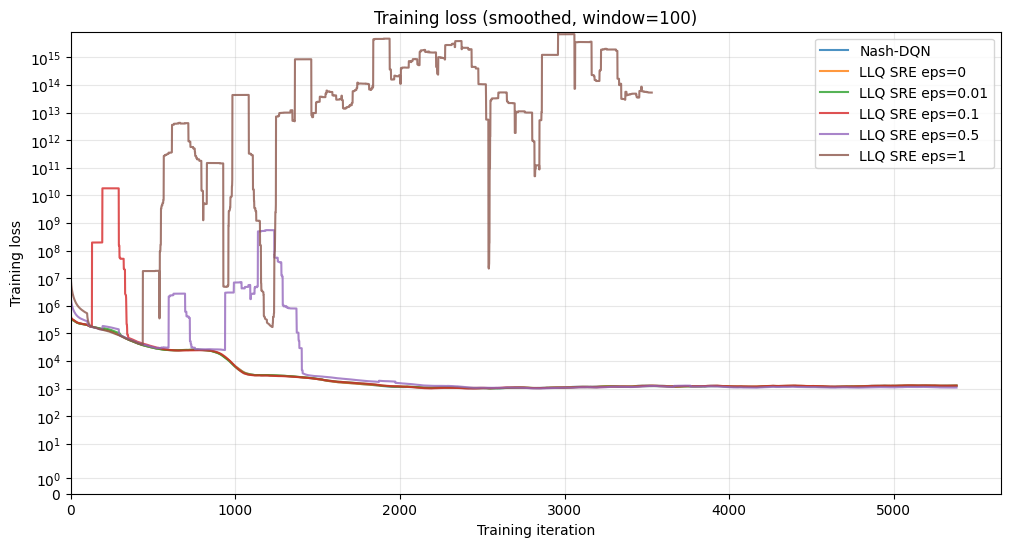

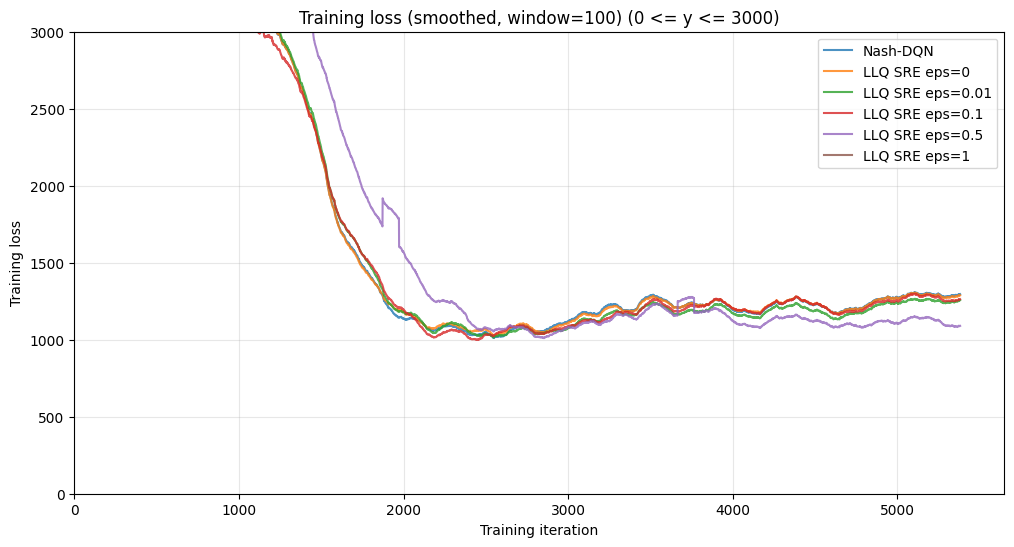

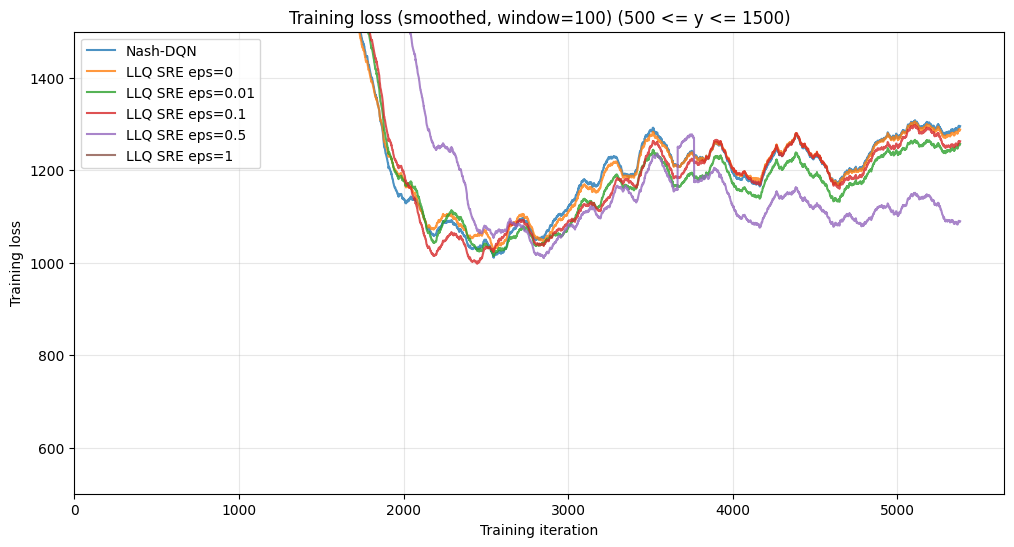

Saved loss plots:
  /home/wowthecoder/SRE-DQN/continuous_action_space/trading_competition/pt_files/training_loss_sweep_seed_42_smoothed.png
  /home/wowthecoder/SRE-DQN/continuous_action_space/trading_competition/pt_files/training_loss_sweep_seed_42_smoothed_y0_3000.png
  /home/wowthecoder/SRE-DQN/continuous_action_space/trading_competition/pt_files/training_loss_sweep_seed_42_smoothed_y500_1500.png


In [15]:
SMOOTH_WINDOW = 100
LOSS_FIGURE_SEED_TAG = seed_slug(BASE_SEED)
LOSS_NORMALIZER = 2 * MINI_BATCH * MAX_STEPS * sim_obj.N
LOSS_SWEEP_PATH = MODEL_ROOT / f'training_mean_loss_sweep_{LOSS_FIGURE_SEED_TAG}_smoothed.png'
LOSS_SWEEP_CLIPPED_PATH = MODEL_ROOT / f'training_mean_loss_sweep_{LOSS_FIGURE_SEED_TAG}_smoothed_y0_0p25.png'
LOSS_SWEEP_ZOOM_PATH = MODEL_ROOT / f'training_mean_loss_sweep_{LOSS_FIGURE_SEED_TAG}_smoothed_y0p04_0p12.png'

def trim_loss_padding(loss):
    loss = list(loss)
    while len(loss) > 1 and loss[-1] == 0:
        loss.pop()
    return loss

def mean_loss(loss):
    return [value / LOSS_NORMALIZER for value in trim_loss_padding(loss)]

def smooth_loss(loss, window=SMOOTH_WINDOW):
    loss = mean_loss(loss)
    if window <= 1 or len(loss) <= 1:
        return loss
    smoothed = []
    running_sum = 0.0
    for idx, value in enumerate(loss):
        running_sum += value
        if idx >= window:
            running_sum -= loss[idx - window]
        current_window = min(idx + 1, window)
        smoothed.append(running_sum / current_window)
    return smoothed

def plot_loss_sweep(output_path, y_limits=None, use_symlog=False, title_suffix=''):
    fig = plt.figure(figsize=(12, 6))
    if nash_loss is not None:
        plt.plot(smooth_loss(nash_loss), label='Nash-DQN', alpha=0.8)
    for eps, loss in llq_sre_losses.items():
        plt.plot(smooth_loss(loss), label=f'LLQ SRE eps={eps:g}', alpha=0.8)
    plt.xlim(left=0)
    plt.margins(x=0)
    if use_symlog:
        plt.yscale('symlog')
    if y_limits is None:
        plt.ylim(bottom=0)
    else:
        plt.ylim(*y_limits)
    title = f'Mean training loss (smoothed, window={SMOOTH_WINDOW})'
    if title_suffix:
        title = f'{title} {title_suffix}'
    plt.title(title)
    plt.xlabel('Training iteration')
    plt.ylabel('Mean training loss')
    plt.legend()
    plt.grid(True, alpha=0.3)
    fig.savefig(output_path, dpi=150, bbox_inches='tight')
    plt.show()

plot_loss_sweep(LOSS_SWEEP_PATH, use_symlog=True)
plot_loss_sweep(LOSS_SWEEP_CLIPPED_PATH, y_limits=(0, 0.25), title_suffix='(0 <= y <= 0.25)')
plot_loss_sweep(LOSS_SWEEP_ZOOM_PATH, y_limits=(0.04, 0.12), title_suffix='(0.04 <= y <= 0.12)')

print('Saved loss plots:')
print(' ', LOSS_SWEEP_PATH)
print(' ', LOSS_SWEEP_CLIPPED_PATH)
print(' ', LOSS_SWEEP_ZOOM_PATH)

## Eval Rewards During Training


In [ ]:
EVAL_REWARD_PATH = MODEL_ROOT / f'eval_reward_during_training_{LOSS_FIGURE_SEED_TAG}.png'

def checkpoint_eval_history(model_dir):
    checkpoint_path = Path(model_dir) / 'final_checkpoint' / 'checkpoint.pt'
    if not checkpoint_path.exists():
        checkpoint_path = Path(model_dir) / 'best_checkpoint' / 'checkpoint.pt'
    if not checkpoint_path.exists():
        return []
    try:
        checkpoint = torch.load(checkpoint_path, map_location='cpu', weights_only=False)
    except TypeError:
        checkpoint = torch.load(checkpoint_path, map_location='cpu')
    return checkpoint.get('extra_state', {}).get('eval_reward_history', [])

def agent_eval_history(agent, model_dir):
    history = getattr(agent, 'eval_reward_history', None) if agent is not None else None
    if history:
        return history
    return checkpoint_eval_history(model_dir)

eval_reward_series = []
nash_history = agent_eval_history(nash_agent, NASH_MODEL_DIR)
if nash_history:
    eval_reward_series.append(('Nash-DQN', nash_history))

for eps in LLQ_SRE_EPS_LIST:
    history = agent_eval_history(llq_sre_agents.get(eps), LLQ_SRE_MODEL_DIRS[eps])
    if history:
        eval_reward_series.append((f'LLQ SRE eps={eps:g}', history))

fig = plt.figure(figsize=(12, 6))
for label, history in eval_reward_series:
    xs = [item['iteration'] for item in history]
    ys = [item['mean_reward'] for item in history]
    plt.plot(xs, ys, marker='o', markersize=3, label=label, alpha=0.85)

plt.xlim(left=0)
plt.margins(x=0)
plt.title('Deterministic eval reward during training')
plt.xlabel('Training iteration')
plt.ylabel('Mean total reward per eval episode')
plt.legend(ncol=2, fontsize=9)
plt.grid(True, alpha=0.3)
fig.savefig(EVAL_REWARD_PATH, dpi=150, bbox_inches='tight')
plt.show()

print('Saved eval reward plot:')
print(' ', EVAL_REWARD_PATH)
